## Final Project Group 8: Sleep and Lifstyle Health

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
df = pd.read_csv('sleep_study_1000.csv')

df.head(12)

,ID,Age,Gender,Bedtime,WakeupTime,SleepDuration,SleepEfficiency,REMSleepPercentage,DeepSleepPercentage,LightSleepPercentage,Awakenings,CaffeineConsumption,AlcoholConsumption,SmokingStatus,ExerciseFrequency
0,1,80,Female,2025-09-30 07:32:17,2025-09-30 13:49:16.669051,6.283241,0.57,15,35,50,0,25.0,1,Yes,1
1,2,24,Male,2025-06-29 20:59:50,2025-06-30 04:09:10.207162,7.155613,0.91,29,68,3,4,50.0,0,No,2
2,3,37,Male,2025-12-24 21:28:32,2025-12-25 03:31:34.257053,6.050627,0.58,15,35,50,3,50.0,0,No,5
3,4,68,Female,2025-02-22 00:25:33,2025-02-22 07:26:37.046703,7.017791,0.88,28,44,28,1,50.0,0,Yes,4
4,5,58,Male,2025-09-02 12:31:53,2025-09-02 21:17:46.256228,8.764793,0.95,28,40,32,4,25.0,4,No,4
5,6,24,Female,2025-10-22 09:37:24,2025-10-22 17:08:54.230234,7.525064,0.86,20,37,43,2,0.0,4,Yes,1
6,7,50,Male,2025-08-24 03:21:41,2025-08-24 08:59:50.703102,5.636029,0.81,15,67,18,3,25.0,2,Yes,5
7,8,72,Female,2025-08-25 18:39:56,2025-08-26 03:20:10.811519,8.670781,0.53,21,35,44,0,NaN,4,No,3
8,9,25,Female,2025-03-21 10:50:20,2025-03-21 18:29:08.313407,7.646754,0.68,25,35,40,2,NaN,2,No,2
9,10,18,Female,2025-08-28 22:29:04,2025-08-29 03:30:56.974751,5.031382,0.76,26,59,15,5,25.0,3,Yes,2


## 1. Dataset check

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    1000 non-null   int64  
 1   Age                   1000 non-null   int64  
 2   Gender                1000 non-null   object 
 3   Bedtime               1000 non-null   object 
 4   WakeupTime            1000 non-null   object 
 5   SleepDuration         1000 non-null   float64
 6   SleepEfficiency       1000 non-null   float64
 7   REMSleepPercentage    1000 non-null   int64  
 8   DeepSleepPercentage   1000 non-null   int64  
 9   LightSleepPercentage  1000 non-null   int64  
 10  Awakenings            1000 non-null   int64  
 11  CaffeineConsumption   744 non-null    float64
 12  AlcoholConsumption    1000 non-null   int64  
 13  SmokingStatus         1000 non-null   object 
 14  ExerciseFrequency     1000 non-null   int64  
dtypes: float64(3), int64(8

In [99]:
df.describe().round(3)

,ID,Age,SleepDuration,SleepEfficiency,REMSleepPercentage,DeepSleepPercentage,LightSleepPercentage,Awakenings,CaffeineConsumption,AlcoholConsumption,ExerciseFrequency
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,744.000,1000.000,1000.000
mean,500.500,50.125,7.027,0.720,22.460,47.357,30.183,2.539,25.168,2.560,2.565
std,288.819,18.076,1.135,0.128,4.589,13.097,13.789,1.727,20.446,1.746,1.713
min,1.000,18.000,5.002,0.500,15.000,25.000,1.000,0.000,0.000,0.000,0.000
25%,250.750,34.000,6.077,0.610,18.000,36.000,18.000,1.000,0.000,1.000,1.000
50%,500.500,51.000,6.982,0.720,22.000,47.000,30.000,3.000,25.000,3.000,3.000
75%,750.250,65.000,8.040,0.830,27.000,59.000,42.000,4.000,50.000,4.000,4.000
max,1000.000,80.000,8.999,0.950,30.000,70.000,59.000,5.000,50.000,5.000,5.000


In [100]:
df.describe(include='object').T

,count,unique,top,freq
Gender,1000,2,Male,513
Bedtime,1000,1000,2025-09-30 07:32:17,1
WakeupTime,1000,1000,2025-09-30 13:49:16.669051,1
SmokingStatus,1000,2,Yes,513


In [101]:
for feature in df.columns:
    print(f'{feature}: {df[feature].unique()[:10]}')
    print('-' * 50)

ID: [ 1  2  3  4  5  6  7  8  9 10]
--------------------------------------------------
Age: [80 24 37 68 58 50 72 25 18 34]
--------------------------------------------------
Gender: ['Female' 'Male']
--------------------------------------------------
Bedtime: ['2025-09-30 07:32:17' '2025-06-29 20:59:50' '2025-12-24 21:28:32'
 '2025-02-22 00:25:33' '2025-09-02 12:31:53' '2025-10-22 09:37:24'
 '2025-08-24 03:21:41' '2025-08-25 18:39:56' '2025-03-21 10:50:20'
 '2025-08-28 22:29:04']
--------------------------------------------------
WakeupTime: ['2025-09-30 13:49:16.669051' '2025-06-30 04:09:10.207162'
 '2025-12-25 03:31:34.257053' '2025-02-22 07:26:37.046703'
 '2025-09-02 21:17:46.256228' '2025-10-22 17:08:54.230234'
 '2025-08-24 08:59:50.703102' '2025-08-26 03:20:10.811519'
 '2025-03-21 18:29:08.313407' '2025-08-29 03:30:56.974751']
--------------------------------------------------
SleepDuration: [6.2832414  7.1556131  6.05062696 7.01779075 8.7647934  7.52506395
 5.63602864 8.67078098

In [102]:
df.duplicated().sum()

np.int64(0)

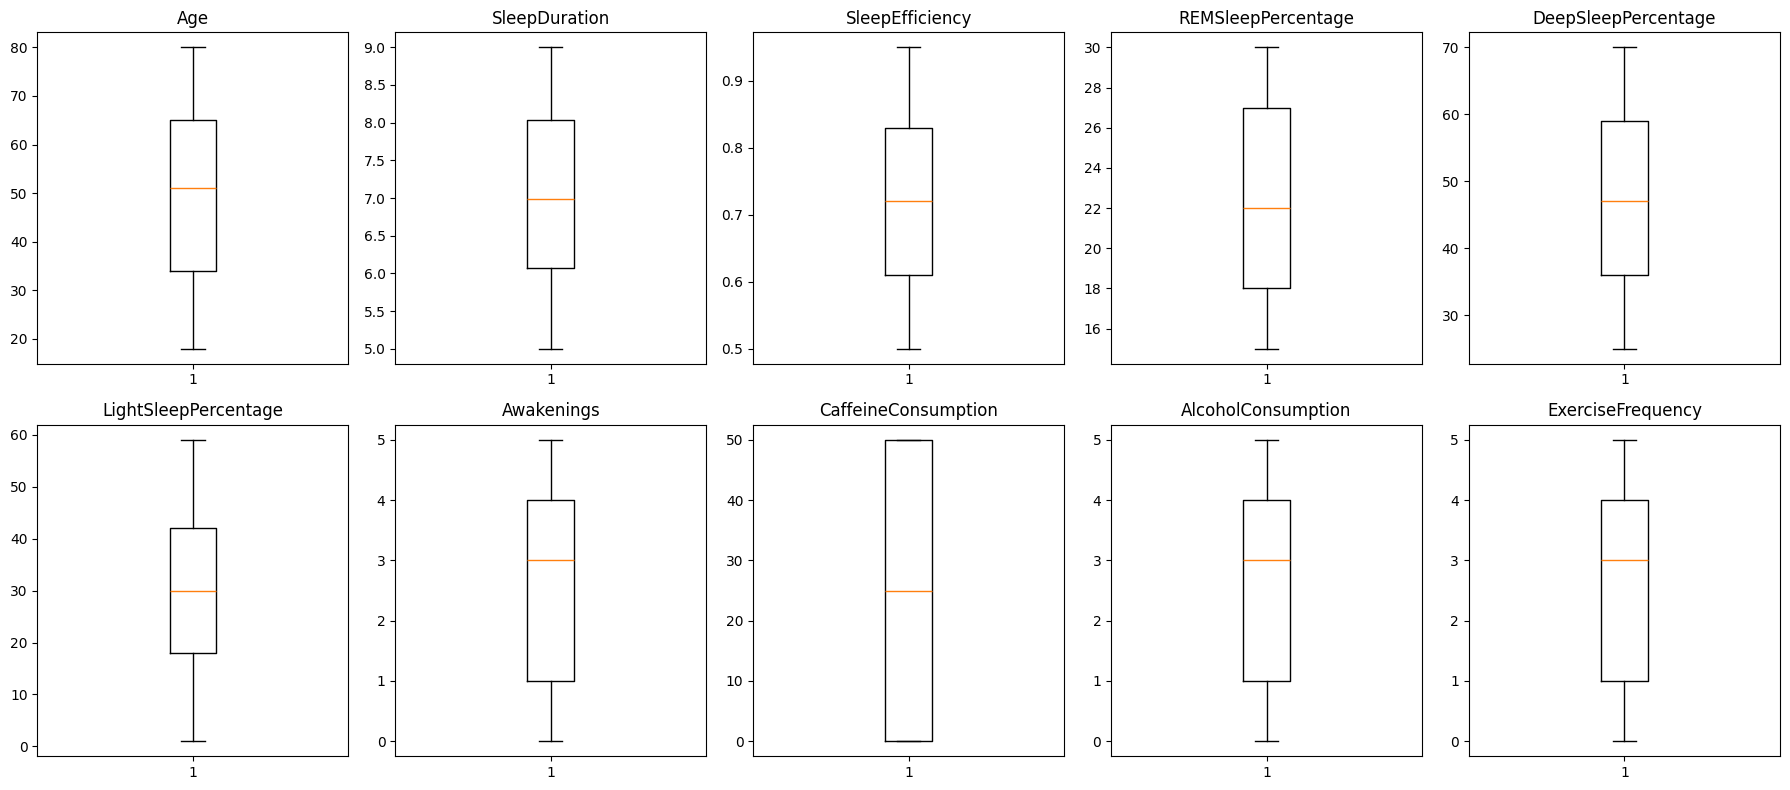

In [103]:
num_features = ['Age', 'SleepDuration', 'SleepEfficiency',
                'REMSleepPercentage', 'DeepSleepPercentage',
                'LightSleepPercentage', 'Awakenings',
                'CaffeineConsumption', 'AlcoholConsumption',
                'ExerciseFrequency']

plt.figure(figsize=(18,8))

for i, col in enumerate(num_features):
    plt.subplot(2, 5, i+1)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

## 2. Data Cleaning

In [104]:
df.drop(columns=['ID'], inplace=True)

In [105]:
missing = df.isnull().sum()
missing_pct = df.isnull().sum() / df.shape[0] * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct.round(2)})
print('Missing Values')
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values
                     Missing Count  Missing (%)
CaffeineConsumption            256         25.6


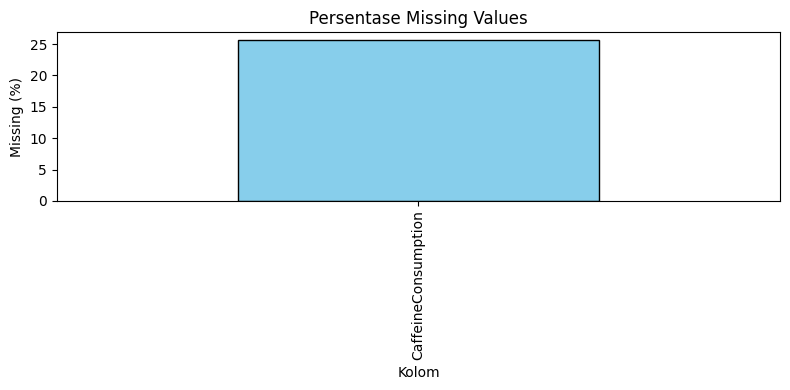

In [106]:
missing_data = missing_pct[missing_pct > 0]

if len(missing_data) > 0:
    plt.figure(figsize=(8, 4))
    missing_data.plot(
        kind='bar',color='skyblue',edgecolor='black'
    )

    plt.title('Persentase Missing Values')
    plt.ylabel('Missing (%)')
    plt.xlabel('Kolom')
    plt.tight_layout()
    plt.show()

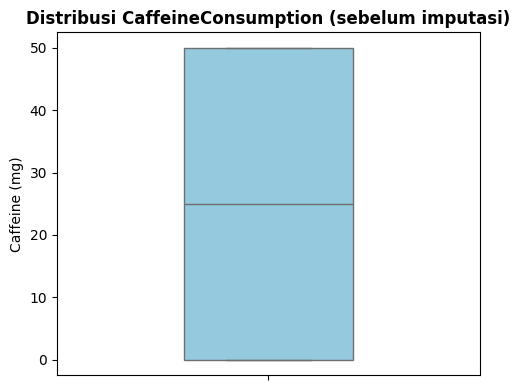

Median CaffeineConsumption: 25.0 mg


In [107]:
plt.figure(figsize=(5, 4))
sns.boxplot(y=df['CaffeineConsumption'], color='skyblue', width=0.4)
plt.title('Distribusi CaffeineConsumption (sebelum imputasi)', fontweight='bold')
plt.ylabel('Caffeine (mg)')
plt.tight_layout()
plt.show()
print(f'Median CaffeineConsumption: {df["CaffeineConsumption"].median()} mg')

In [123]:
median_caffeine = df['CaffeineConsumption'].median()
df['CaffeineConsumption'].fillna(median_caffeine, inplace=True)
print(f'Missing values dengan median: {median_caffeine} mg')
print(f'missing values: {df.isnull().sum().sum()}')

Missing values dengan median: 25.0 mg
missing values: 0


/var/folders/v3/nyw6ps3j0yvg52l6fpz2_qnm0000gn/T/ipykernel_3770/1333391370.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CaffeineConsumption'].fillna(median_caffeine, inplace=True)


In [109]:
df['Bedtime'] = pd.to_datetime(df['Bedtime'])
df['WakeupTime'] = pd.to_datetime(df['WakeupTime'])

df['BedtimeHour'] = df['Bedtime'].dt.hour
df['WakeupHour'] = df['WakeupTime'].dt.hour

df[['Bedtime', 'BedtimeHour', 'WakeupTime', 'WakeupHour']].head(5)

,Bedtime,BedtimeHour,WakeupTime,WakeupHour
0,2025-09-30 07:32:17,7,2025-09-30 13:49:16.669051,13
1,2025-06-29 20:59:50,20,2025-06-30 04:09:10.207162,4
2,2025-12-24 21:28:32,21,2025-12-25 03:31:34.257053,3
3,2025-02-22 00:25:33,0,2025-02-22 07:26:37.046703,7
4,2025-09-02 12:31:53,12,2025-09-02 21:17:46.256228,21


In [110]:
df.info()
print(f'\nMissing values: {df.isnull().sum().sum()} ')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Age                   1000 non-null   int64         
 1   Gender                1000 non-null   object        
 2   Bedtime               1000 non-null   datetime64[ns]
 3   WakeupTime            1000 non-null   datetime64[ns]
 4   SleepDuration         1000 non-null   float64       
 5   SleepEfficiency       1000 non-null   float64       
 6   REMSleepPercentage    1000 non-null   int64         
 7   DeepSleepPercentage   1000 non-null   int64         
 8   LightSleepPercentage  1000 non-null   int64         
 9   Awakenings            1000 non-null   int64         
 10  CaffeineConsumption   1000 non-null   float64       
 11  AlcoholConsumption    1000 non-null   int64         
 12  SmokingStatus         1000 non-null   object        
 13  ExerciseFrequency  

## 3. Visualization

/var/folders/v3/nyw6ps3j0yvg52l6fpz2_qnm0000gn/T/ipykernel_3770/2411286648.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Age', palette='Set2', ax=axes[1])


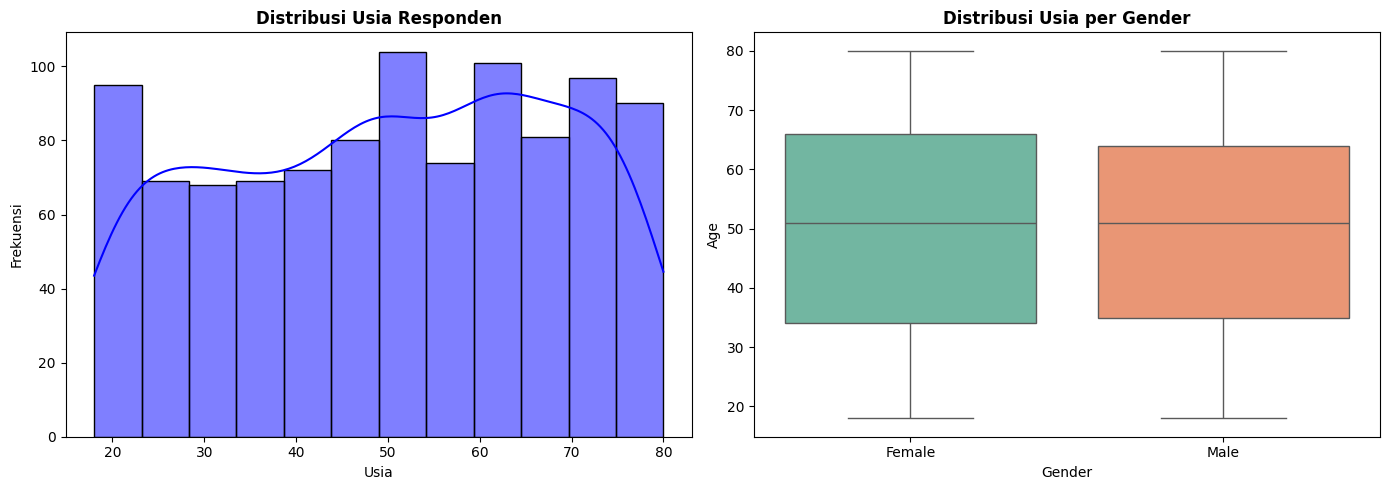

Rata-rata usia : 50.1 tahun
Usia termuda  : 18 tahun
Usia tertua   : 80 tahun


In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Age', binwidth=5, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribusi Usia Responden', fontweight='bold')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Frekuensi')

sns.boxplot(data=df, x='Gender', y='Age', palette='Set2', ax=axes[1])
axes[1].set_title('Distribusi Usia per Gender', fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Rata-rata usia : {df["Age"].mean():.1f} tahun')
print(f'Usia termuda  : {df["Age"].min()} tahun')
print(f'Usia tertua   : {df["Age"].max()} tahun')

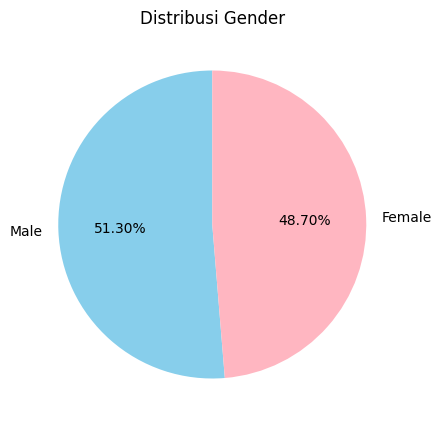

Gender
Male      513
Female    487
Name: count, dtype: int64


In [112]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    gender_counts,labels=gender_counts.index,autopct='%.2f%%',colors=['skyblue', 'lightpink'],startangle=90
)

plt.title('Distribusi Gender')

plt.show()

print(df['Gender'].value_counts())

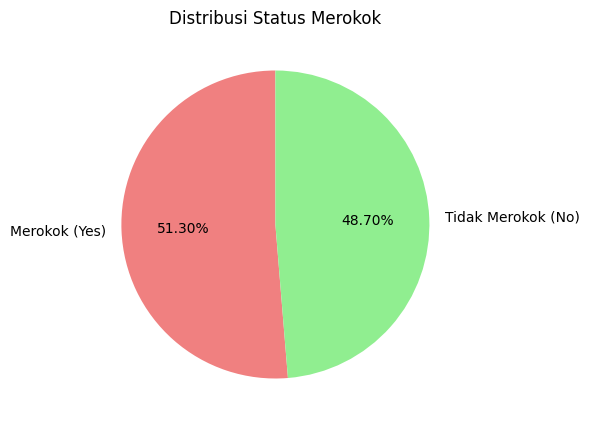

SmokingStatus
Yes    513
No     487
Name: count, dtype: int64


In [113]:
smoke_counts = df['SmokingStatus'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    smoke_counts,
    labels=['Merokok (Yes)', 'Tidak Merokok (No)'],
    autopct='%.2f%%',
    colors=['lightcoral', 'lightgreen'],
    startangle=90
)

plt.title('Distribusi Status Merokok')

plt.show()

print(df['SmokingStatus'].value_counts())

/var/folders/v3/nyw6ps3j0yvg52l6fpz2_qnm0000gn/T/ipykernel_3770/3519723770.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


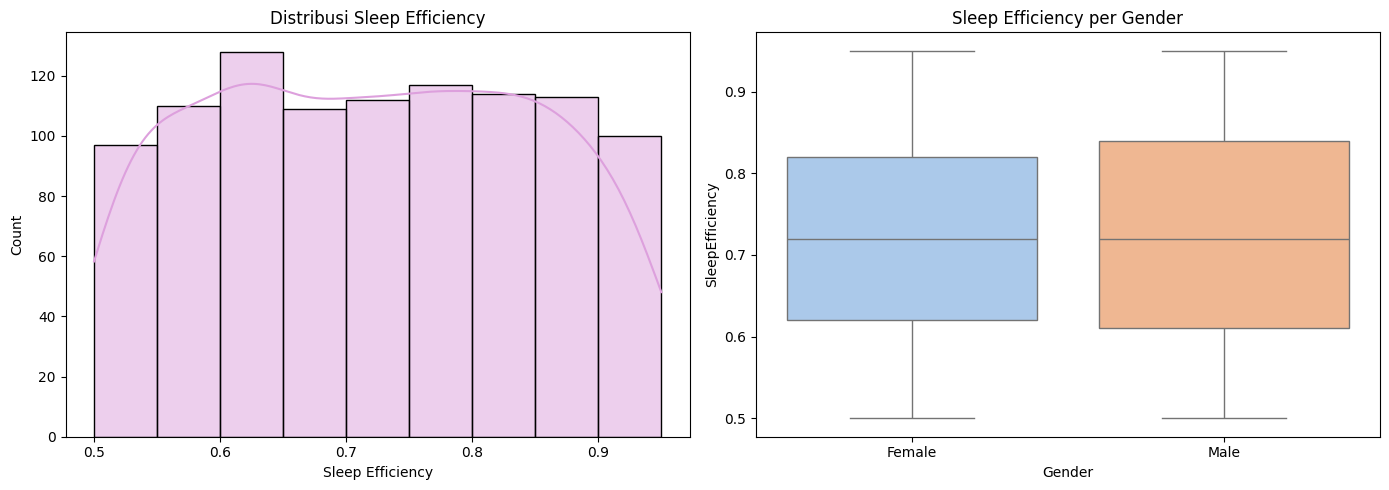

Rata-rata Sleep Efficiency : 0.720
Min: 0.50
Max: 0.95


In [114]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,x='SleepEfficiency',binwidth=0.05,kde=True,color='plum',ax=axes[0]
)

axes[0].set_title('Distribusi Sleep Efficiency')
axes[0].set_xlabel('Sleep Efficiency')

sns.boxplot(
    data=df,x='Gender',y='SleepEfficiency',palette='pastel',ax=axes[1]
)

axes[1].set_title('Sleep Efficiency per Gender')

plt.tight_layout()
plt.show()

print(f'Rata-rata Sleep Efficiency : {df["SleepEfficiency"].mean():.3f}')
print(f'Min: {df["SleepEfficiency"].min():.2f}')
print(f'Max: {df["SleepEfficiency"].max():.2f}')

/var/folders/v3/nyw6ps3j0yvg52l6fpz2_qnm0000gn/T/ipykernel_3770/2455971909.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


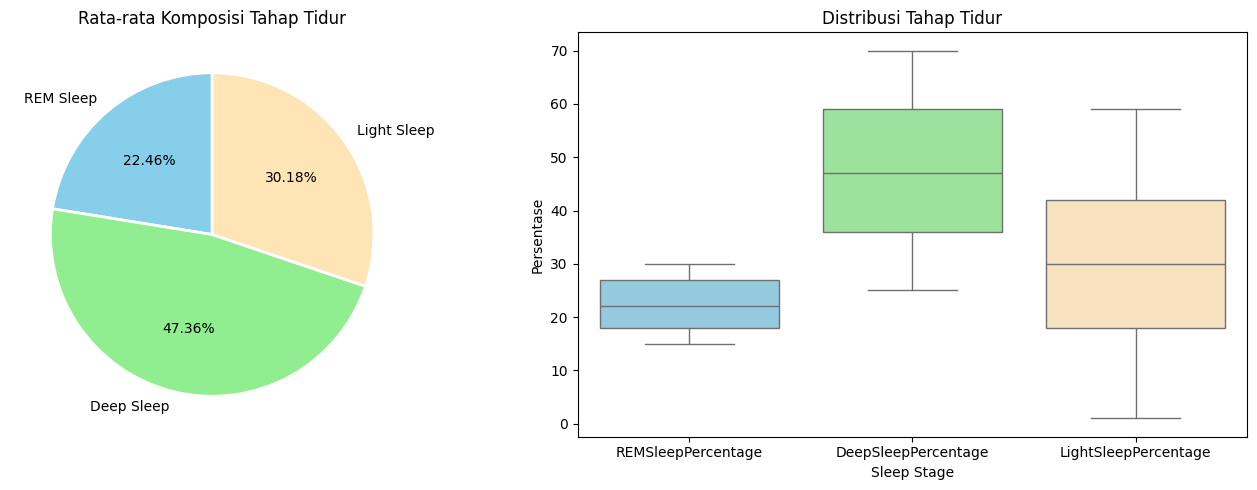

In [115]:
sleep_stages = df[['REMSleepPercentage',
                   'DeepSleepPercentage',
                   'LightSleepPercentage']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    sleep_stages,
    labels=['REM Sleep', 'Deep Sleep', 'Light Sleep'],
    autopct='%.2f%%',
    colors=['skyblue', 'lightgreen', 'moccasin'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

axes[0].set_title('Rata-rata Komposisi Tahap Tidur')

df_melt = df[[
    'REMSleepPercentage','DeepSleepPercentage','LightSleepPercentage'
]].melt(
    var_name='Sleep Stage',
    value_name='Persentase'
)

sns.boxplot(
    data=df_melt,
    x='Sleep Stage',
    y='Persentase',
    palette=['skyblue', 'lightgreen', 'moccasin'],
    ax=axes[1]
)

axes[1].set_title('Distribusi Tahap Tidur')

plt.tight_layout()
plt.show()

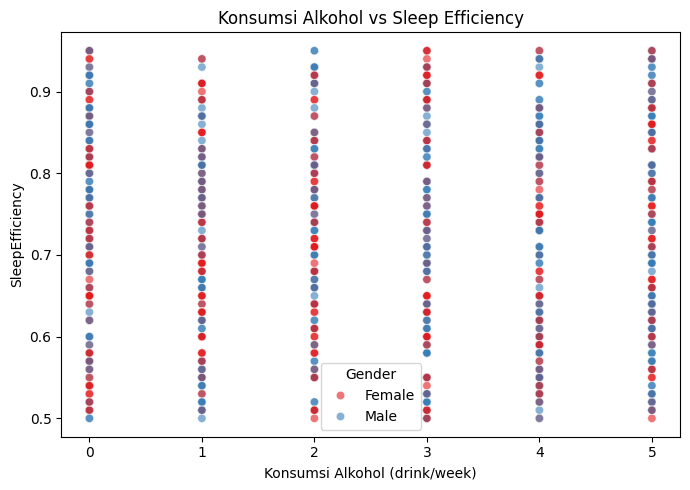

In [116]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df, x='AlcoholConsumption', y='SleepEfficiency',hue='Gender',alpha=0.6,palette='Set1'
)

plt.title('Konsumsi Alkohol vs Sleep Efficiency')
plt.xlabel('Konsumsi Alkohol (drink/week)')

plt.tight_layout()
plt.show()

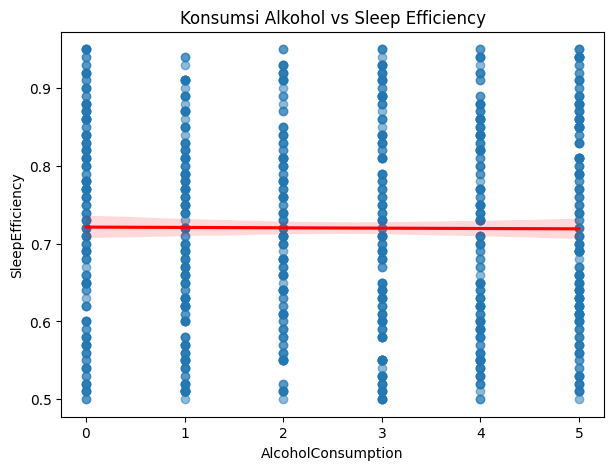

In [117]:
plt.figure(figsize=(7,5))

sns.regplot(
    data=df,x='AlcoholConsumption',y='SleepEfficiency',scatter_kws={'alpha':0.5},line_kws={'color':'red'}
)

plt.title('Konsumsi Alkohol vs Sleep Efficiency')

plt.show()

/var/folders/v3/nyw6ps3j0yvg52l6fpz2_qnm0000gn/T/ipykernel_3770/3856107385.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_eff_exercise, x='ExerciseFrequency', y='SleepEfficiency',


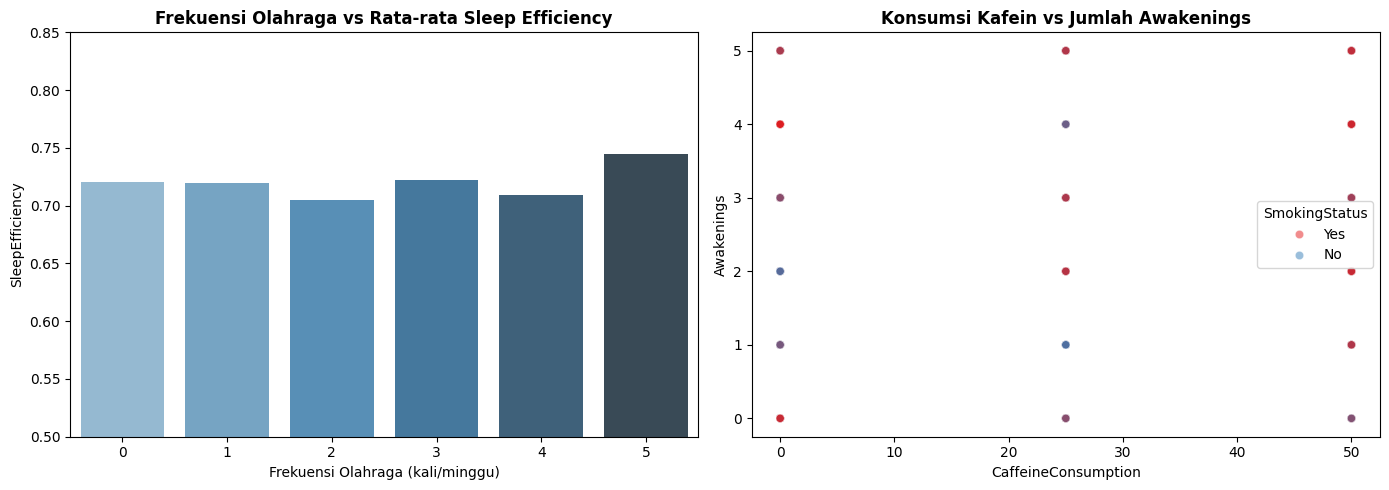

Rata-rata Sleep Efficiency per Frekuensi Olahraga
 ExerciseFrequency  SleepEfficiency
                 0         0.720349
                 1         0.720000
                 2         0.705197
                 3         0.721910
                 4         0.709005
                 5         0.745000


In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_eff_exercise = df.groupby('ExerciseFrequency')['SleepEfficiency'].mean().reset_index()
sns.barplot(data=avg_eff_exercise, x='ExerciseFrequency', y='SleepEfficiency',
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Frekuensi Olahraga vs Rata-rata Sleep Efficiency', fontweight='bold')
axes[0].set_xlabel('Frekuensi Olahraga (kali/minggu)')
axes[0].set_ylim(0.5, 0.85)

sns.scatterplot(data=df, x='CaffeineConsumption', y='Awakenings',
                hue='SmokingStatus', alpha=0.5, ax=axes[1], palette='Set1')
axes[1].set_title('Konsumsi Kafein vs Jumlah Awakenings', fontweight='bold')

plt.tight_layout()
plt.show()
print('Rata-rata Sleep Efficiency per Frekuensi Olahraga')
print(avg_eff_exercise.to_string(index=False))

/var/folders/v3/nyw6ps3j0yvg52l6fpz2_qnm0000gn/T/ipykernel_3770/169077334.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Gender', y='SleepDuration', palette='Set2', ax=axes[1])


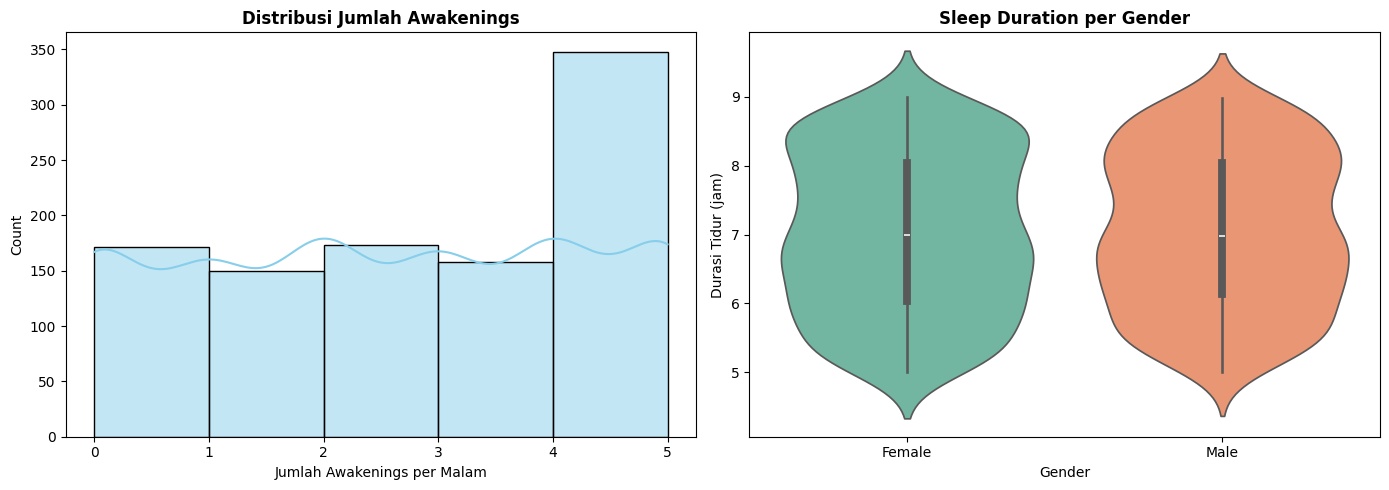

Rata-rata durasi tidur : 7.03 jam
Rata-rata awakenings   : 2.54 kali/malam


In [119]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Awakenings', binwidth=1, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribusi Jumlah Awakenings', fontweight='bold')
axes[0].set_xlabel('Jumlah Awakenings per Malam')

sns.violinplot(data=df, x='Gender', y='SleepDuration', palette='Set2', ax=axes[1])
axes[1].set_title('Sleep Duration per Gender', fontweight='bold')
axes[1].set_ylabel('Durasi Tidur (jam)')

plt.tight_layout()
plt.show()
print(f'Rata-rata durasi tidur : {df["SleepDuration"].mean():.2f} jam')
print(f'Rata-rata awakenings   : {df["Awakenings"].mean():.2f} kali/malam')

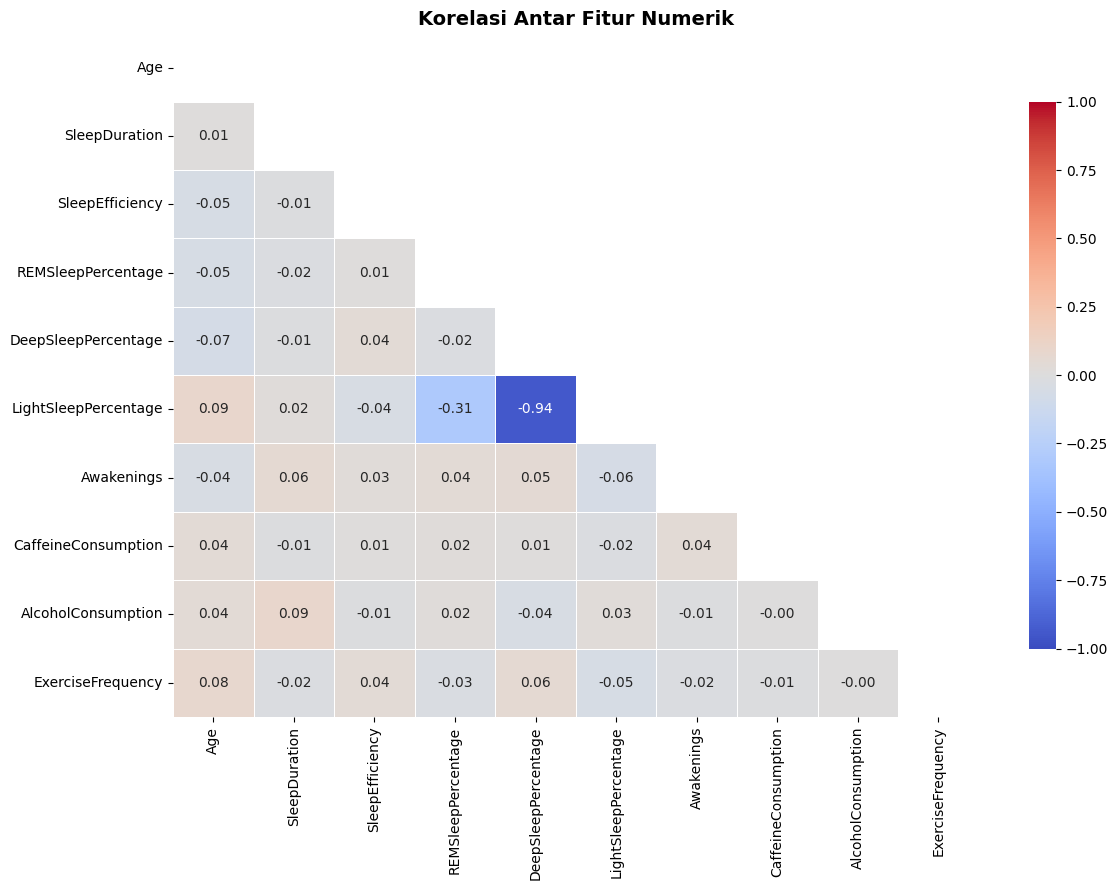


Korelasi dengan Sleep Efficiency
Age                    -0.05
DeepSleepPercentage     0.04
LightSleepPercentage   -0.04
ExerciseFrequency       0.04
Awakenings              0.03
SleepDuration          -0.01
REMSleepPercentage      0.01
CaffeineConsumption     0.01
AlcoholConsumption     -0.01
Name: SleepEfficiency, dtype: float64


In [120]:
num_cols = ['Age', 'SleepDuration', 'SleepEfficiency', 'REMSleepPercentage',
            'DeepSleepPercentage', 'LightSleepPercentage', 'Awakenings',
            'CaffeineConsumption', 'AlcoholConsumption', 'ExerciseFrequency']

corr = df[num_cols].corr().round(2)

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKorelasi dengan Sleep Efficiency')
print(corr['SleepEfficiency'].drop('SleepEfficiency').sort_values(key=abs, ascending=False))

hasil sleep effiesience agak aneh soalnya hampir dekat 0

/var/folders/v3/nyw6ps3j0yvg52l6fpz2_qnm0000gn/T/ipykernel_3770/653905520.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='AgeGroup', y='SleepEfficiency', palette='pastel', ax=axes[0])
/var/folders/v3/nyw6ps3j0yvg52l6fpz2_qnm0000gn/T/ipykernel_3770/653905520.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='AlcoholGroup', y='SleepEfficiency', palette='Reds', ax=axes[1])


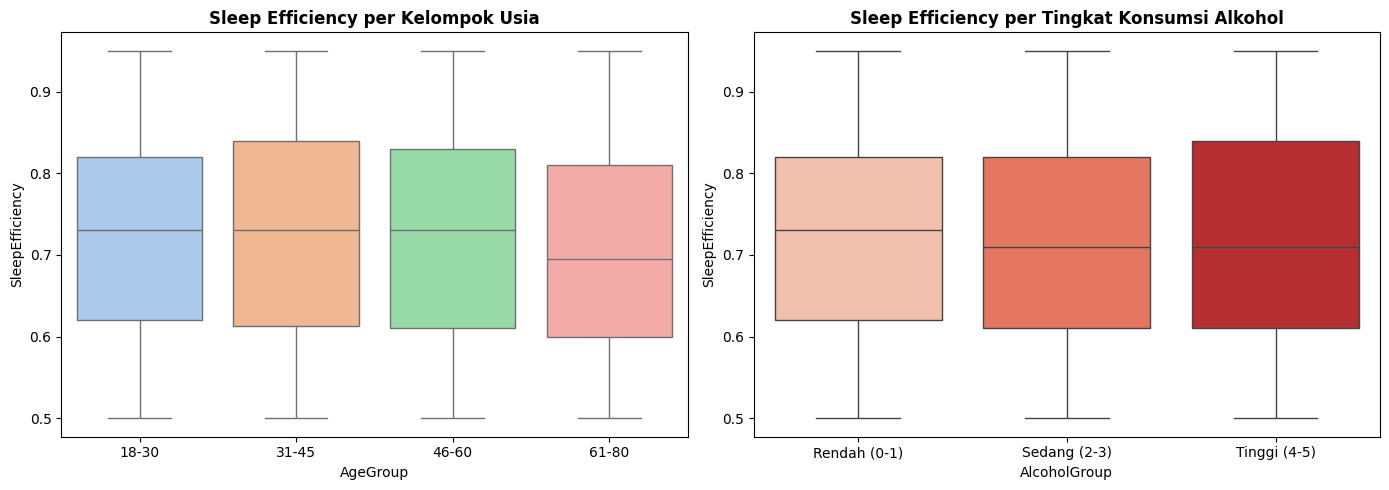

Rata-rata Sleep Efficiency per Kelompok Usia
AgeGroup
18-30    0.724
31-45    0.731
46-60    0.723
61-80    0.709
Name: SleepEfficiency, dtype: float64


In [121]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 30, 45, 60, 80],
                         labels=['18-30', '31-45', '46-60', '61-80'])
df['AlcoholGroup'] = pd.cut(df['AlcoholConsumption'], bins=[-1, 1, 3, 5],
                             labels=['Rendah (0-1)', 'Sedang (2-3)', 'Tinggi (4-5)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='AgeGroup', y='SleepEfficiency', palette='pastel', ax=axes[0])
axes[0].set_title('Sleep Efficiency per Kelompok Usia', fontweight='bold')

sns.boxplot(data=df, x='AlcoholGroup', y='SleepEfficiency', palette='Reds', ax=axes[1])
axes[1].set_title('Sleep Efficiency per Tingkat Konsumsi Alkohol', fontweight='bold')

plt.tight_layout()
plt.show()
print('Rata-rata Sleep Efficiency per Kelompok Usia')
print(df.groupby('AgeGroup', observed=True)['SleepEfficiency'].mean().round(3))

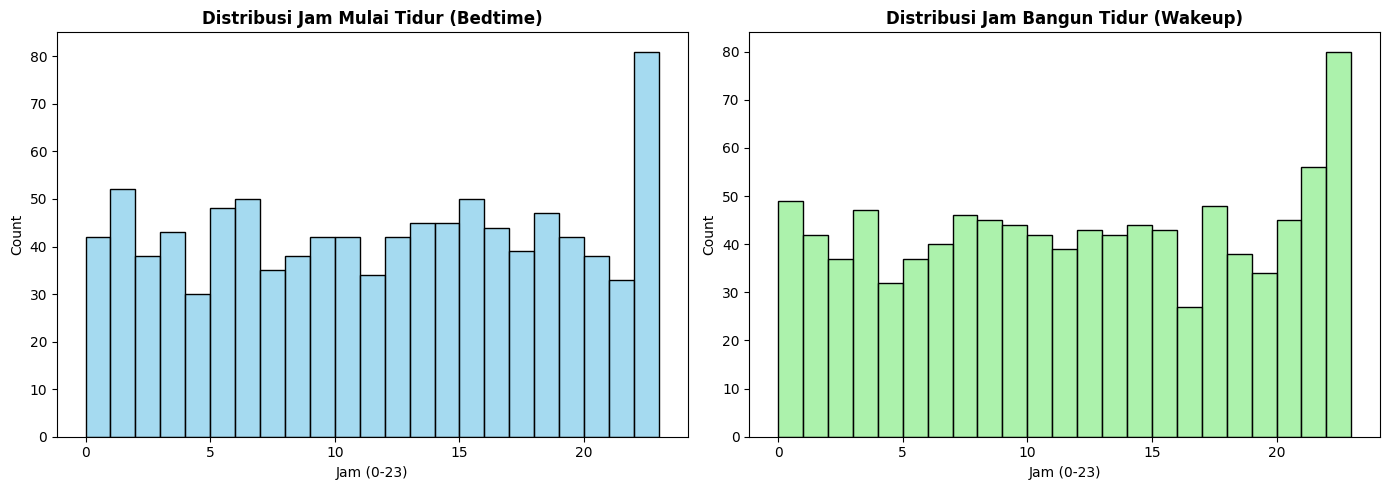

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='BedtimeHour', binwidth=1, color='skyblue', ax=axes[0])
axes[0].set_title('Distribusi Jam Mulai Tidur (Bedtime)', fontweight='bold')
axes[0].set_xlabel('Jam (0-23)')

sns.histplot(data=df, x='WakeupHour', binwidth=1, color='lightgreen', ax=axes[1])
axes[1].set_title('Distribusi Jam Bangun Tidur (Wakeup)', fontweight='bold')
axes[1].set_xlabel('Jam (0-23)')

plt.tight_layout()
plt.show()